# Converters

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
working_directory = "/Users/kemalinecik/git_nosync/sctram"

In [3]:
import sys
sys.path.append(working_directory)

import logging
import os
import numpy as np
import pandas as pd
import networkx as nx
import scanpy as sc
import anndata as ad
from scipy.stats import pearsonr, spearmanr

sc.settings.verbosity = 3

In [4]:
from sctram.evaluate._converters._adjacency2pseudotime import AdjacencyPseudotimeConverter, LabelAdjacencyPseudotimeConverter
from sctram.evaluate._converters._pseudotime2adjacency import PseudotimeAdjacencyConverter, PseudotimeLabelAdjacencyConverter
from sctram.evaluate._converters._diffmap2adjacency import DiffmapAdjacencyConverter
from sctram.generate.real import sc_datasets_paul15

from sctram.infer._paga import PAGAInference
from sctram.infer._dpt import DPTInference
from sctram.infer._diffmap import DiffmapEmbedding

In [5]:
%matplotlib inline
%config InlineBackend.figure_format='retina'
import matplotlib.pyplot as plt
import seaborn as sns

import pickle
_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, 'rb') as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

## Dataset, DPT, PAGA, Diffmap

computing neighbors
computing PCA
    with n_comps=50


/Users/kemalinecik/tools/apps/mamba/envs/sctram_dev_env/lib/python3.11/site-packages/scanpy/tools/_utils.py:41: UserWarning: You’re trying to run this on 3451 dimensions of `.X`, if you really want this, set `use_rep='X'`.
         Falling back to preprocessing with `sc.pp.pca` and default params.
  warnings.warn(


    finished (0:00:00)
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:03)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:03)
computing Diffusion Maps using n_comps=15(=n_dcs)
computing transitions
    finished (0:00:00)
    eigenvalues of transition matrix
    [1.         0.9972308  0.99191815 0.9733054  0.97111243 0.9500587
     0.9467936  0.9421937  0.93553513 0.9207576  0.90654033 0.89805615
     0.8875245  0.87663406 0.8629513 ]
    finished: added
    'X_diffmap', diffmap coordinates (adata.obsm)
    'diffmap_evals', eigenvalues of transition matrix (adata.uns) (0:00:00)


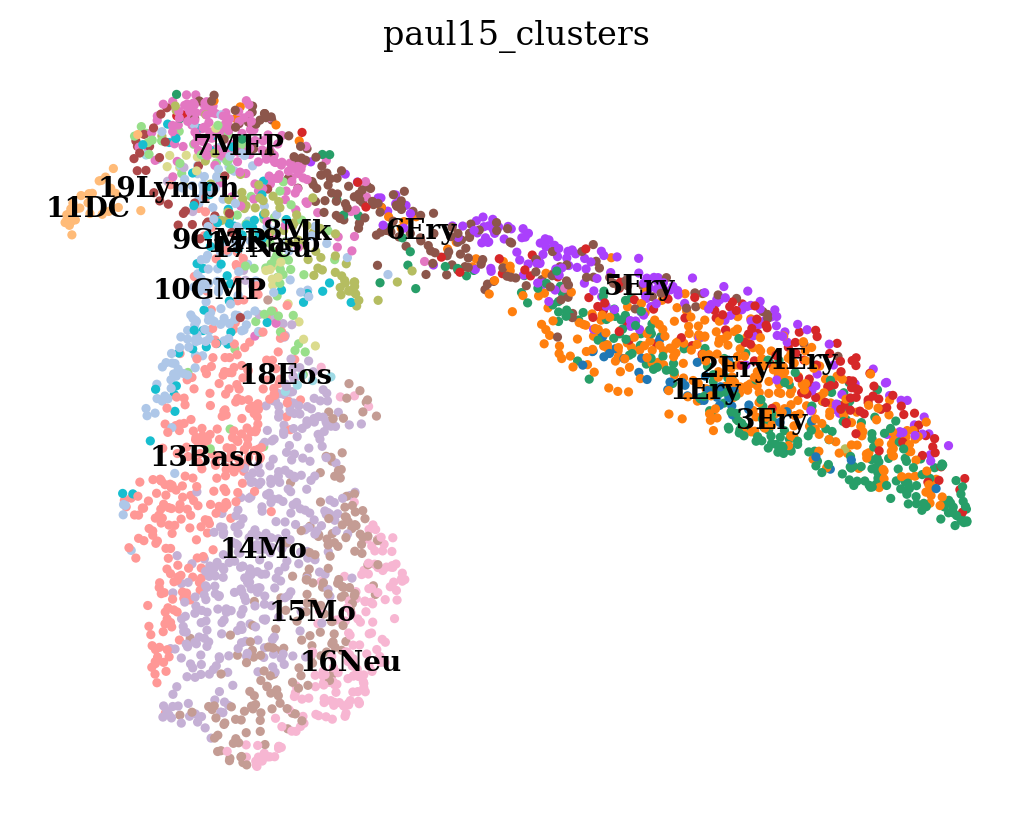

Index(['1Ery', '2Ery', '3Ery', '4Ery', '5Ery', '6Ery', '7MEP', '8Mk', '9GMP',
       '10GMP', '11DC', '12Baso', '13Baso', '14Mo', '15Mo', '16Neu', '17Neu',
       '18Eos', '19Lymph'],
      dtype='object')

In [6]:
dataset_dir = "/Users/kemalinecik/git_nosync/sctram/__temp__/data"
adata = sc_datasets_paul15(dataset_dir=dataset_dir)
sc.pp.neighbors(adata=adata, n_neighbors=30)
sc.tl.umap(adata)
sc.tl.diffmap(adata)
sc.pl.umap(adata, color=["paul15_clusters"], frameon=False, legend_loc="on data")
adata.obs["paul15_clusters"].cat.categories

In [7]:
paga_inference = PAGAInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90}, 
    adata=adata, 
    labels=adata.obs["paul15_clusters"]
)
paga_inference.calculate()
adjacency_matrix = paga_inference.get_result("adjacency")
adjacency_matrix_labels = paga_inference.get_result("labels")

INFO:PAGAInference:Starting PAGAInference trajectory inference.
INFO:PAGAInference:Performing trajectory inference.
INFO:PAGAInference:Using precomputed neighbors from AnnData.


running PAGA
    finished: added
    'paga/connectivities', connectivities adjacency (adata.uns)
    'paga/connectivities_tree', connectivities subtree (adata.uns) (0:00:00)


INFO:PAGAInference:Trajectory inference completed successfully.


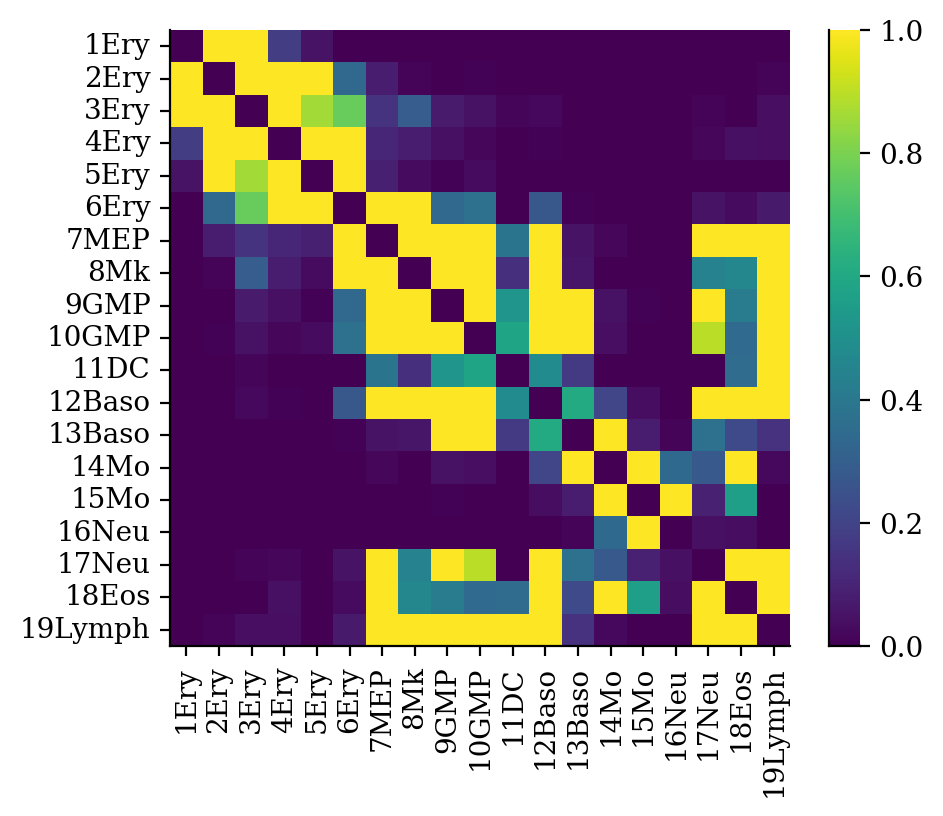

In [8]:
adjacency_matrix_df = pd.DataFrame(adjacency_matrix, columns=adjacency_matrix_labels, index=adjacency_matrix_labels)
plt.figure(figsize=(5, 4))
sns.heatmap(adjacency_matrix_df, cmap='viridis')
sns.despine()
plt.show()

In [31]:
root_label = "1Ery"

In [32]:
iroot_params = {
    "label_key": "paul15_clusters",
    "label": root_label,
    "method": "min_diffmap",
    "outlier_definition_z": 3
}
dpt_inference = DPTInference(
    random_state=42, 
    neighbors_params={"n_neighbors": 90},
    iroot_params=iroot_params,
    adata=adata, 
    labels=adata.obs["paul15_clusters"]
)
dpt_inference.calculate()
pseudotime = dpt_inference.get_result("vector")

INFO:DPTInference:Starting DPTInference trajectory inference.
INFO:DPTInference:Performing trajectory inference.
INFO:DPTInference:Using precomputed neighbors from AnnData.
INFO:DPTInference:Diffusion Map is already calculated.
INFO:DPTInference:Outlier removal applied. 43 out of 43 cells remain after filtering based on z-score <= 3.
INFO:DPTInference:Root set to cell index 613 based on minimum in DiffMap component 0 within label '1Ery'.
INFO:DPTInference:Performing DPT trajectory calculation.


computing Diffusion Pseudotime using n_dcs=10
    finished: added
    'dpt_pseudotime', the pseudotime (adata.obs) (0:00:00)


INFO:DPTInference:Trajectory inference completed successfully.


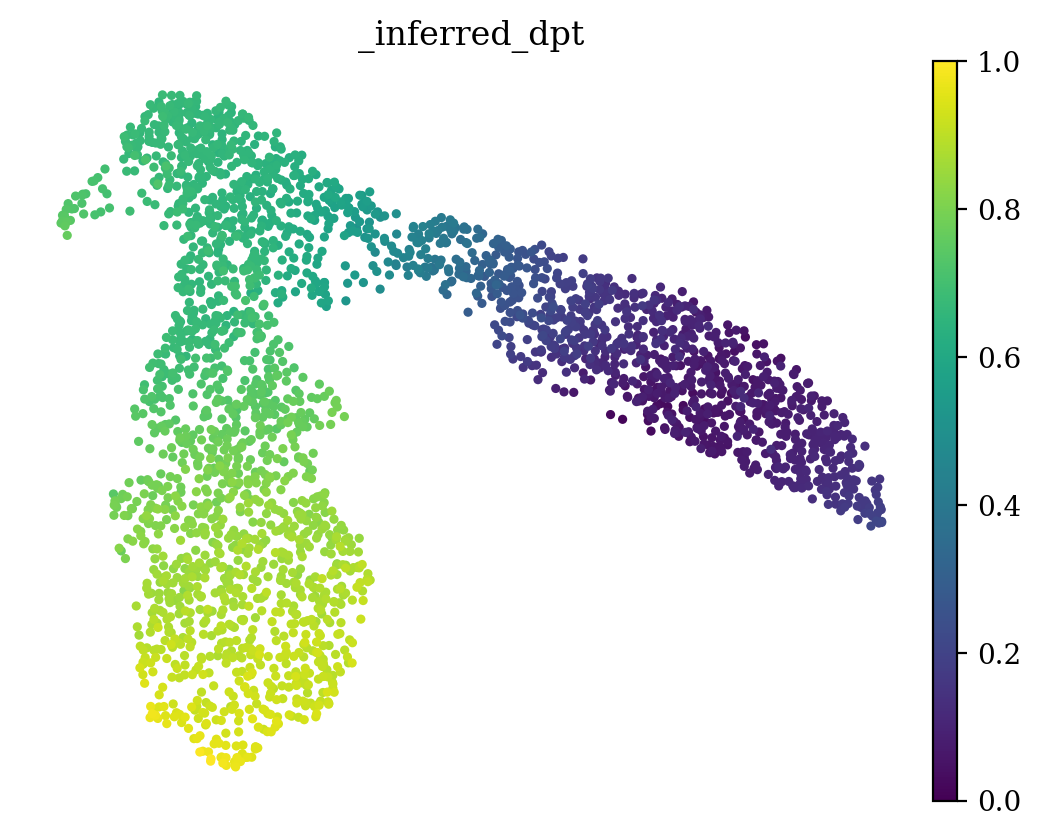

In [33]:
adata.obs["_inferred_dpt"] = pseudotime
sc.pl.umap(adata, color=["_inferred_dpt"], frameon=False)

In [34]:
embedding_object = DiffmapEmbedding(
    random_state=42,
    neighbors_params={"n_neighbors": 90},
    diffmap_params=None, 
    adata=adata, 
    labels=adata.obs["paul15_clusters"]
)
embedding_object.calculate()
diffmap = embedding_object.get_result("diffmap")

INFO:DiffmapEmbedding:Starting DiffmapEmbedding embedding calculation.
INFO:DiffmapEmbedding:Performing embedding calculation.
INFO:DiffmapEmbedding:Using precomputed neighbors from AnnData.
INFO:DiffmapEmbedding:Diffusion Map is already calculated.
INFO:DiffmapEmbedding:Embedding calculation completed successfully.


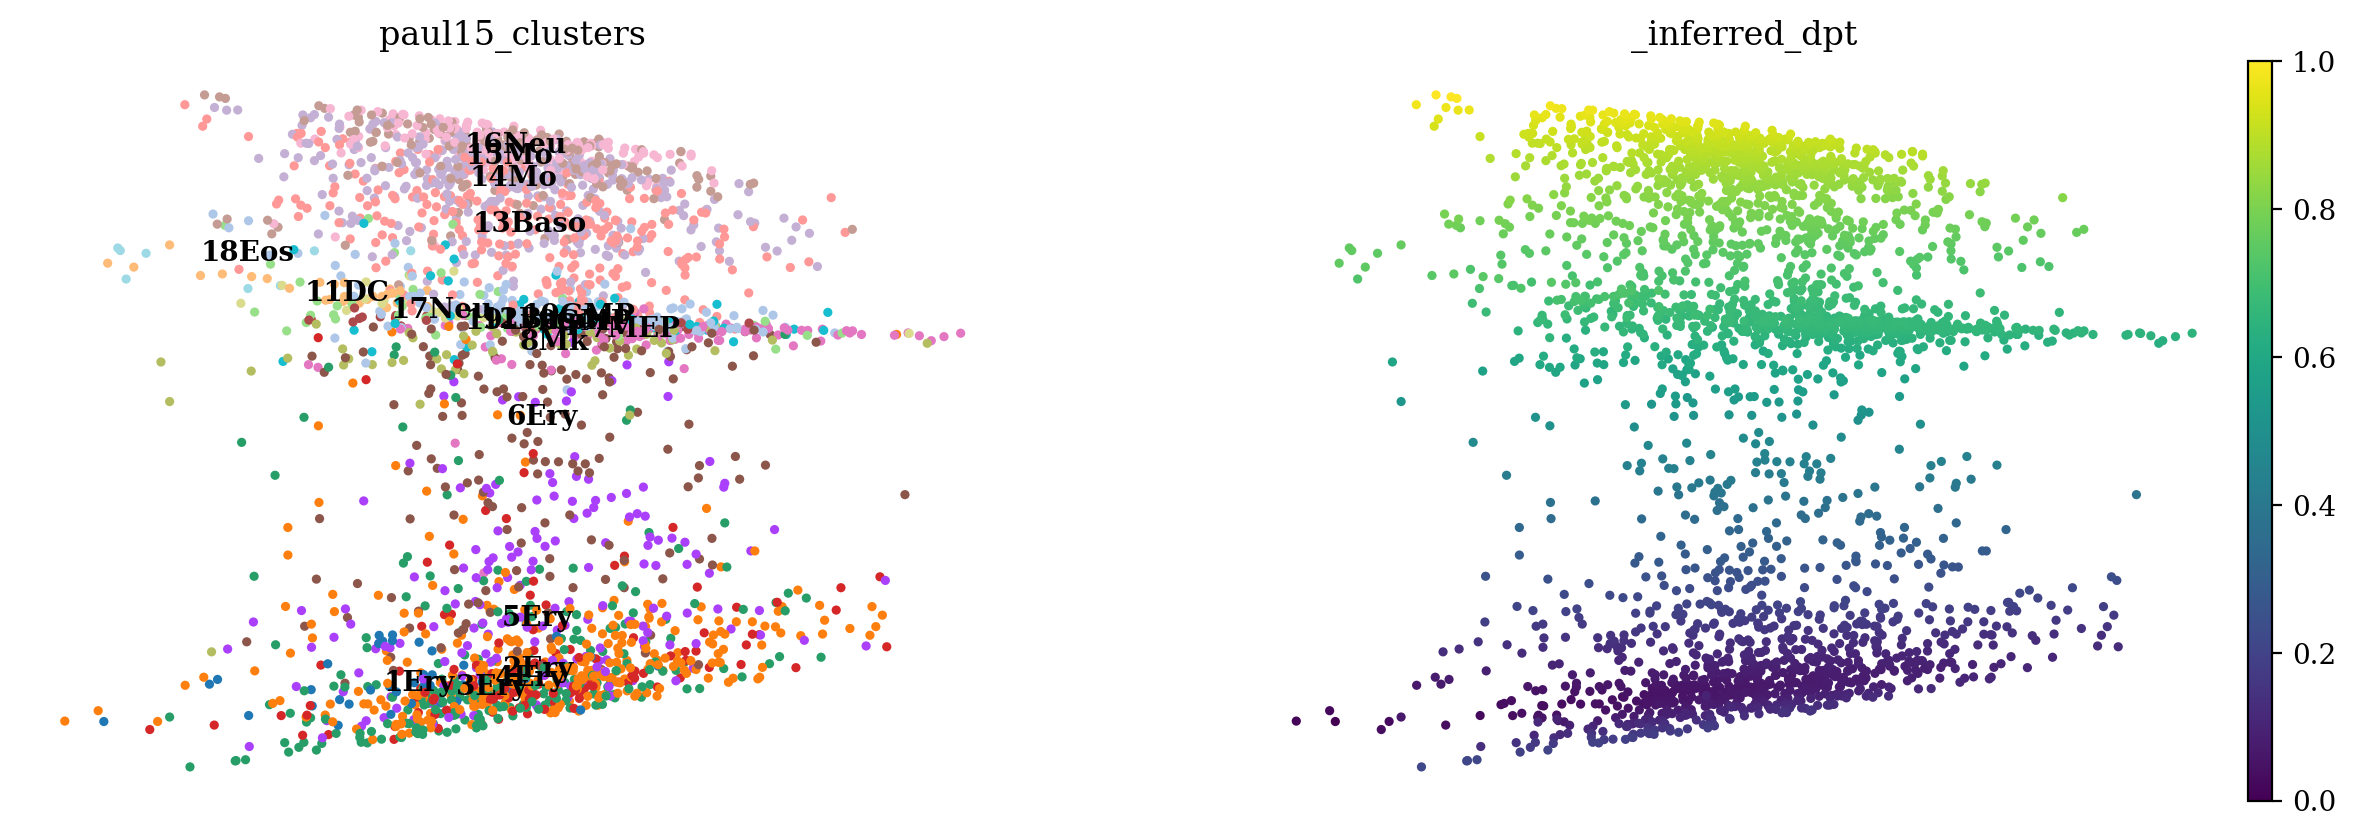

In [35]:
sc.pl.diffmap(embedding_object.get_result("anndata"), color=["paul15_clusters", "_inferred_dpt"], frameon=False, legend_loc="on data")

In [36]:
adata

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters', '_inferred_dpt'
    uns: 'iroot', 'pca', 'neighbors', 'umap', 'diffmap_evals', 'paul15_clusters_colors'
    obsm: 'X_pca', 'X_umap', 'X_diffmap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'

## Converter Adjacency to Pseutotime

In [37]:
root_index = np.where(adjacency_matrix_labels == root_label)[0][0]
cell_labels = np.array(list(adata.obs["paul15_clusters"]))
converter = LabelAdjacencyPseudotimeConverter(
    adjacency_matrix, 
    label_adjacency_matrix_labels=adjacency_matrix_labels,
    cell_labels=cell_labels
)

In [38]:
def check_conversion(cell_pseudotime, label_pseudotime):
    print("Cell Pseudotime:")

    df_plot = pd.DataFrame({
        "inferred": pseudotime,
        "converted": cell_pseudotime,
        "labels": cell_labels})
    plt.figure(figsize=(3,3))
    sns.scatterplot(data=df_plot, x="inferred", y="converted", hue="labels", legend=False, linewidth=0)
    sns.despine()
    plt.show()

    print("spearman:", spearmanr(pseudotime, cell_pseudotime))
    print("pearson:", pearsonr(pseudotime, cell_pseudotime))

    print("\nLabel Pseudotime:")

    mean_pseudotime = np.array([pseudotime[cell_labels == cat].mean() for cat in adjacency_matrix_labels])

    df_plot = pd.DataFrame({
        "inferred": mean_pseudotime,
        "converted": label_pseudotime,
        "labels": adjacency_matrix_labels})
    plt.figure(figsize=(3,3))
    sns.scatterplot(data=df_plot, x="inferred", y="converted", hue="labels", legend=False, linewidth=0)
    sns.despine()
    plt.show()

    print("spearman:", spearmanr(mean_pseudotime, label_pseudotime))
    print("pearson:", pearsonr(mean_pseudotime, label_pseudotime))
    
    adata.obs["_inferred_dpt"] = cell_pseudotime
    _, ax = plt.subplots(figsize=(5, 3))
    sc.pl.umap(adata, color=["_inferred_dpt"], frameon=False, show=False, ax=ax, size=15)
    plt.show()
    
    _, ax = plt.subplots(figsize=(5, 3))
    sc.pl.diffmap(adata, color=["_inferred_dpt"], frameon=False, show=False, ax=ax, size=15)
    plt.show()

Cell Pseudotime:


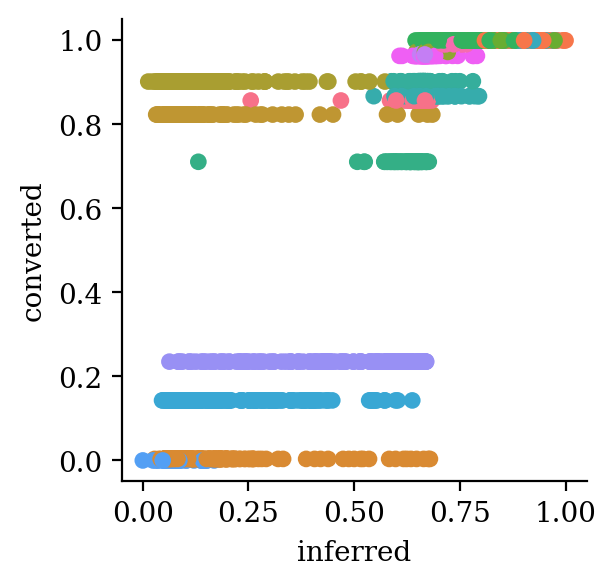

spearman: SignificanceResult(statistic=0.8150651019655606, pvalue=0.0)
pearson: PearsonRResult(statistic=0.6167355403286462, pvalue=7.399748105772102e-286)

Label Pseudotime:


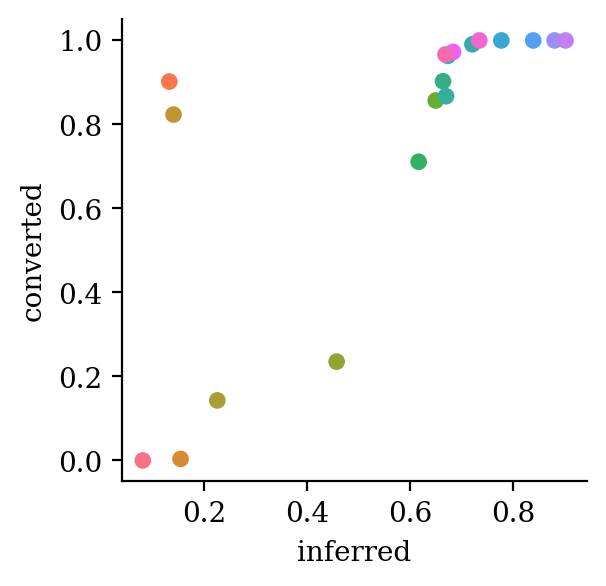

spearman: SignificanceResult(statistic=0.9115401189586655, pvalue=5.6900230008318427e-08)
pearson: PearsonRResult(statistic=0.7338013373545547, pvalue=0.00034880088872784747)


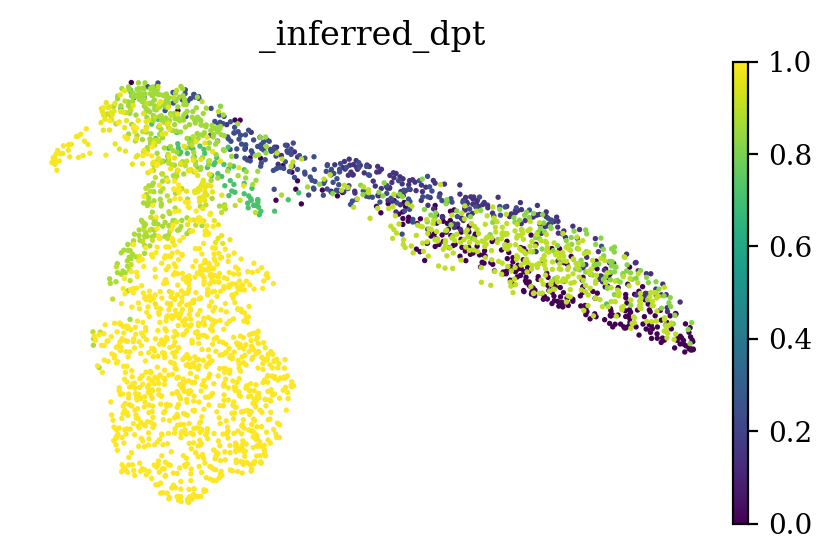

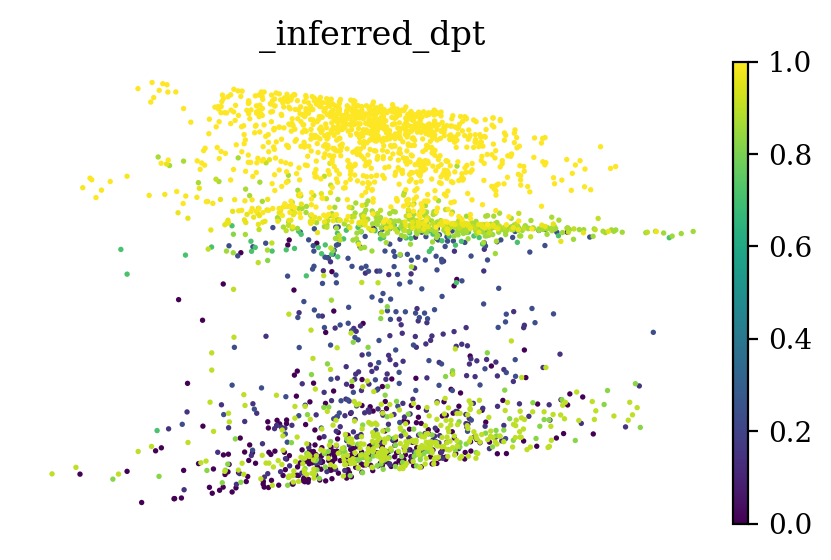

In [39]:
label_pseudotime = converter.get_label_pseudotime(method="shortest_path", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="shortest_path", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime)

Diffusion pseudotime converged in 15 steps.
Diffusion pseudotime converged in 15 steps.
Cell Pseudotime:


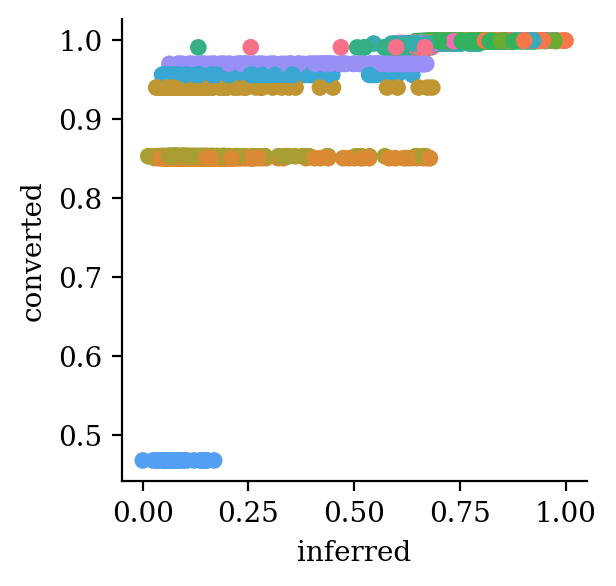

spearman: SignificanceResult(statistic=0.936068607016563, pvalue=0.0)
pearson: PearsonRResult(statistic=0.7018744459865556, pvalue=0.0)

Label Pseudotime:


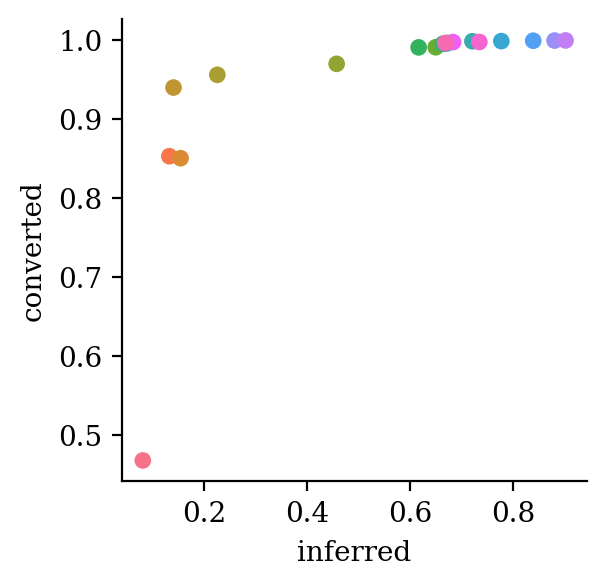

spearman: SignificanceResult(statistic=0.9912280701754386, pvalue=2.200851783163643e-16)
pearson: PearsonRResult(statistic=0.6794946550870082, pvalue=0.001374237206255279)


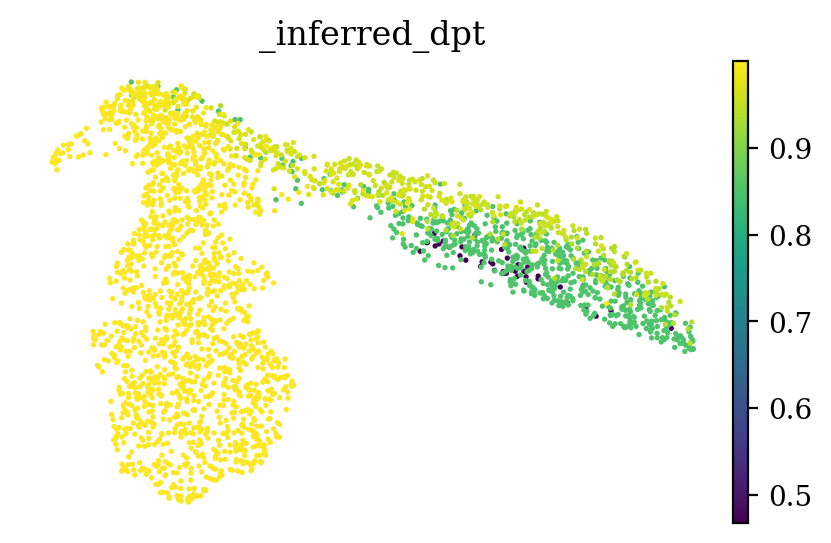

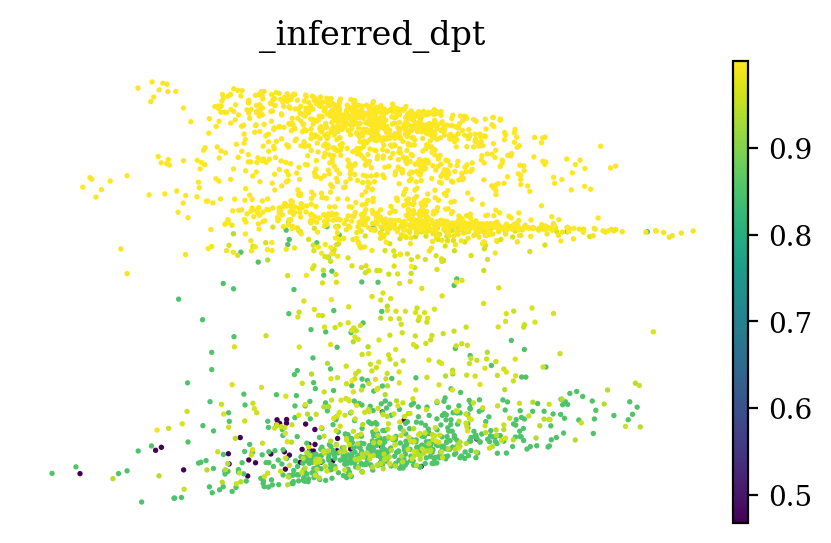

In [40]:
label_pseudotime = converter.get_label_pseudotime(method="diffusion_with_damping", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="diffusion_with_damping", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime)

Cell Pseudotime:


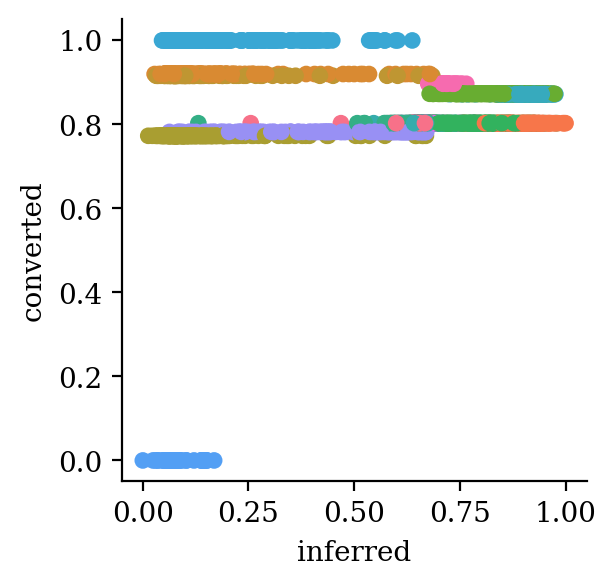

spearman: SignificanceResult(statistic=0.08400444994916528, pvalue=1.1080238469062496e-05)
pearson: PearsonRResult(statistic=0.042754929948553136, pvalue=0.025488474651289842)

Label Pseudotime:


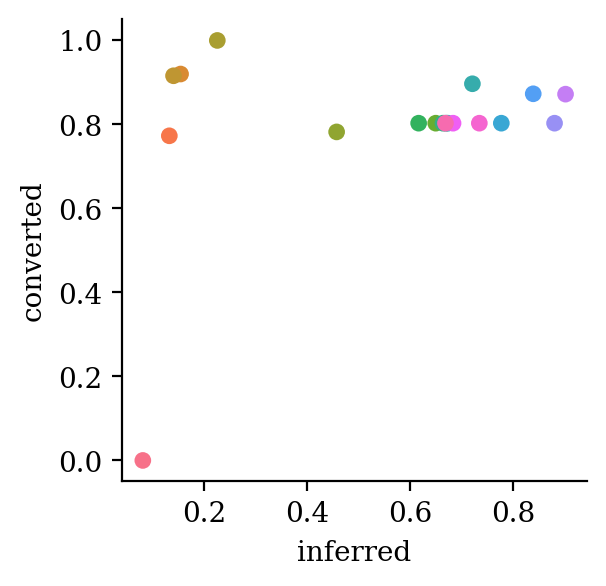

spearman: SignificanceResult(statistic=0.2138344515277114, pvalue=0.37938188816782803)
pearson: PearsonRResult(statistic=0.3001068037454805, pvalue=0.21190369881851834)


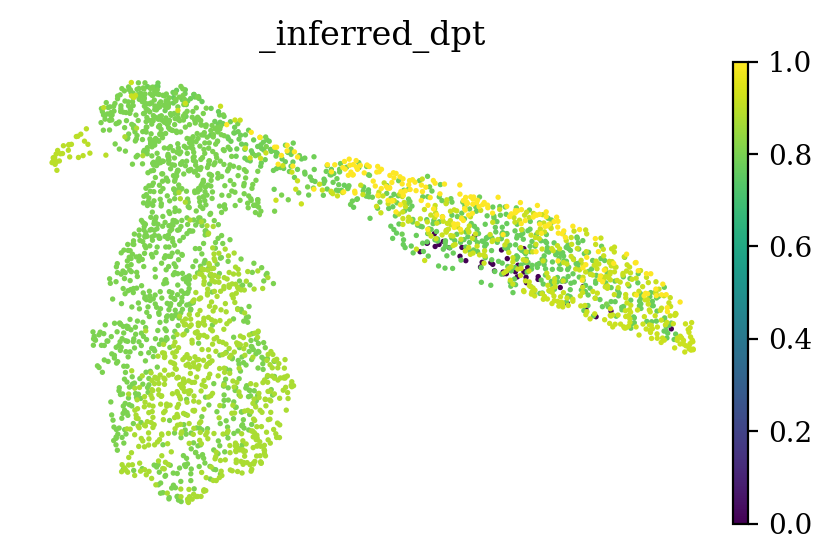

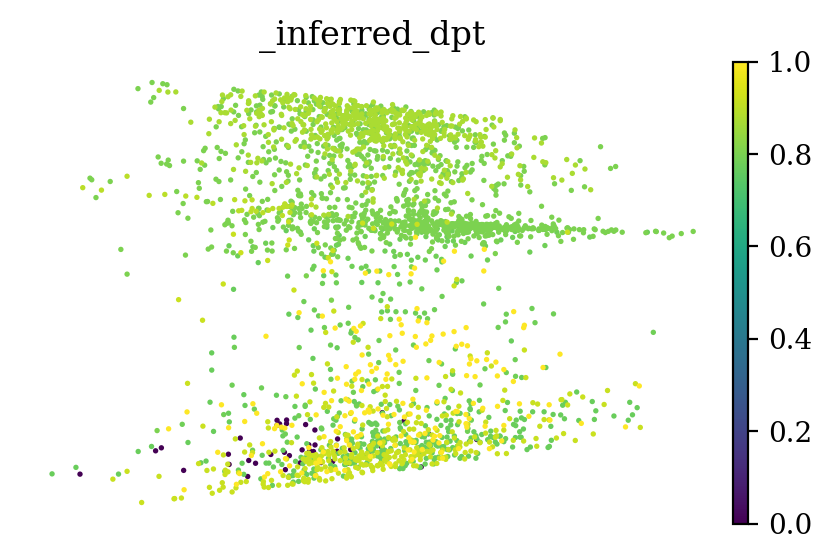

In [41]:
label_pseudotime = converter.get_label_pseudotime(method="diffusion_with_eigen", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="diffusion_with_eigen", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime)

Cell Pseudotime:


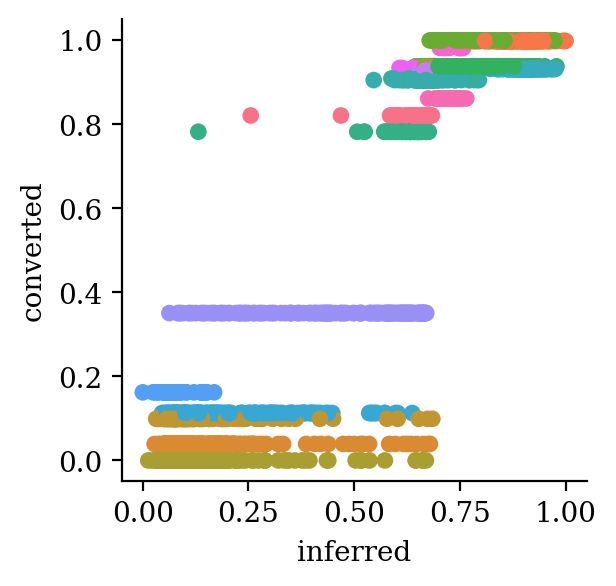

spearman: SignificanceResult(statistic=0.8836919219320328, pvalue=0.0)
pearson: PearsonRResult(statistic=0.9351945853101804, pvalue=0.0)

Label Pseudotime:


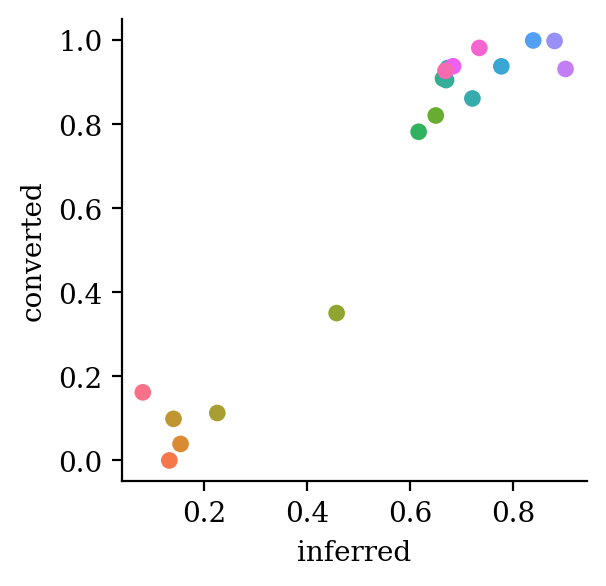

spearman: SignificanceResult(statistic=0.9, pvalue=1.549793446868578e-07)
pearson: PearsonRResult(statistic=0.9635095637455705, pvalue=3.664634711232811e-11)


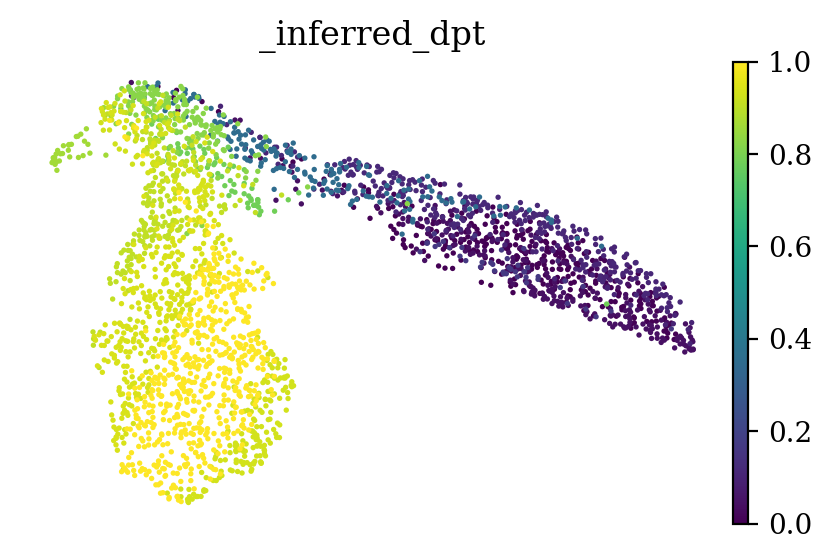

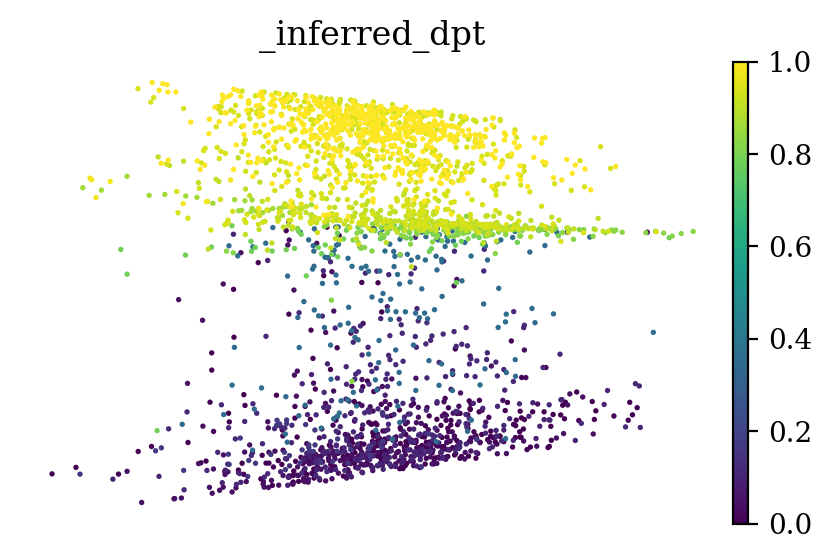

In [42]:
label_pseudotime = converter.get_label_pseudotime(method="spectral", root_label=root_index)
cell_pseudotime = converter.get_cell_pseudotime(method="spectral", root_label=root_index)
check_conversion(cell_pseudotime, label_pseudotime)

## Converter Pseudotime to Adjacency